# 0607 — cGAN TSTR: Train-Synthetic-Test-Real Validation

Validates the cGAN's synthetic manifold by training two versions of the same XGBoost "bouncer" classifier — one on real data (TRTR: Train-Real-Test-Real), one on synthetic data (TSTR: Train-Synthetic-Test-Real) — and comparing both against a held-out real Week 6. Predictive parity between the two tells us whether the synthetic manifold is a usable stand-in for real data.

```mermaid
flowchart TD
    A["BigQuery: v_ML_Supervised (real)\nsynthetic_manifold_v8_enriched (synthetic)"] --> B["Phase 1\nBlueprint: features + target"]
    B --> C["Phase 2\nTRTR: extract, unify products,\ntrain on real W1-5, evaluate on real W6"]
    C --> D["trtr_f1 (baseline)"]
    C --> E["Phase 3\nTSTR: train on synthetic manifold,\nevaluate on same real W6 holdout"]
    E --> F["tstr_f1 (challenger)"]
    D --> G["Predictive parity verdict\ntstr_f1 / trtr_f1"]
    F --> G
    classDef default stroke:#21918c,stroke-width:2px;
    linkStyle default stroke:#21918c,stroke-width:2px;
```


## Phase 1 — Setup

Authenticate the BigQuery client, define the plot palette, and lay out the feature/target blueprint shared by both extraction queries.

#### 1.1 — Cloud bootstrap & visual canon

Authenticate the BigQuery client and set the Pienza plot palette.

In [11]:
import os
import re
import warnings

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from google.cloud import bigquery
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')

# --- Credentials ---
SA_PATH = "/workspaces/pienza/secrets/service-account.json"
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = SA_PATH

# --- Project coordinates ---
PROJECT_ID = 'drivers-dilemma'  # text alias for clarity
DATASET_MINI = 'pienza_mini'
DATASET_BIG = 'pienza_big'

client = bigquery.Client(project=PROJECT_ID)

# --- Pienza visual canon ---
PIENZA_PURPLE = '#440154'
PIENZA_TEAL = '#21918c'
PIENZA_GREY = '#FAFAFA'
PIENZA_TEXT = '#333333'
cmap_pienza_teal = mcolors.LinearSegmentedColormap.from_list("pienza_teal", ["#FFFFFF", PIENZA_TEAL])

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'figure.facecolor': PIENZA_GREY,
    'axes.facecolor': PIENZA_GREY,
    'axes.titlecolor': PIENZA_PURPLE,
    'figure.titlesize': 20,
    'figure.titleweight': 'bold'
})

print(f"Connected: {PROJECT_ID} ready for the chronological schism.")


Connected: drivers-dilemma ready for the chronological schism.


#### 1.2 — Schema probe

Quick check of the synthetic manifold's columns before building the feature blueprint.

In [12]:
# Quick schema probe
query = f"""
    SELECT column_name, data_type
    FROM `{PROJECT_ID}.{DATASET_BIG}.INFORMATION_SCHEMA.COLUMNS`
    WHERE table_name = 'synthetic_manifold_v8_enriched'
"""
df_schema_big = client.query(query).to_dataframe()
print(df_schema_big['column_name'].tolist())


['upfront_fare', 'est_trip_time_sec', 'est_trip_dist_km', 'time_to_pickup_sec', 'dist_to_pickup_km', 'hour_of_day', 'day_of_week', 'product_category_fk', 'dropoff_zone_id', 'pickup_zone_id', 'reason_primary_fk', 'product_name', 'dropoff_name', 'pickup_name']


#### 1.3 — Feature & target blueprint

Defines the feature set and target column shared by both the real and synthetic extraction queries.

In [13]:
print("Defining the dimensional blueprint (strict GAN schema)...")

# Physical and semantic features (timestamp is not a feature)
CORE_FEATURES = [
    'upfront_fare',
    'est_trip_time_sec',
    'est_trip_dist_km',
    'time_to_pickup_sec',
    'dist_to_pickup_km',
    'hour_of_day',
    'day_of_week',
    'product_category_fk', 'product_name',
    'dropoff_zone_id', 'dropoff_name',
    'pickup_zone_id', 'pickup_name'
]

TARGET = 'reason_primary_fk'
QUERY_COLUMNS = CORE_FEATURES + [TARGET]

print(f"Blueprint set: {len(CORE_FEATURES)} features + 1 target")


Defining the dimensional blueprint (strict GAN schema)...
Blueprint set: 13 features + 1 target


## Phase 2 — TRTR: reality baseline

Extracts real and synthetic data, unifies product tiers, trains the XGBoost bouncer on real data only, evaluates it on the Week 6 holdout, and purges the rare class-7 (system failure) category.

#### 2.1 — Dual-lake extraction & chronological schism (TRTR)

Pulls the synthetic manifold and the real data (with a SQL-side semantic translation layer so both sets share the same schema), then splits the real data chronologically: weeks 1-5 for training, week 6 held out for testing.

In [14]:
# Protocol: SOP 0607 | Version: 260506
# Status: 100% Colab parity, no modifications applied.
print("Starting dual-lake extraction and chronological schism...")

# --- 1. Synthetic ingest (df_synth) ---
sql_select_synth = ", ".join([f"`{col}`" for col in QUERY_COLUMNS])
query_synth = f"SELECT {sql_select_synth} FROM `{PROJECT_ID}.{DATASET_BIG}.synthetic_manifold_v8_enriched`"

print("   Downloading synthetic manifold...")
df_synth = client.query(query_synth).to_dataframe()
print(f"   df_synth in memory: {df_synth.shape[0]:,} rows.")

# --- 2. Real ingest (df_real_full), with semantic SQL translation ---
real_columns_sql = []
for col in QUERY_COLUMNS:
    if col == 'product_name':
        real_columns_sql.append("CASE WHEN product_category_fk = 1 THEN 'X' WHEN product_category_fk = 2 THEN 'Mid-Tier' WHEN product_category_fk = 3 THEN 'Premium' ELSE 'Unknown' END AS product_name")
    elif col == 'dropoff_zone_id':
        real_columns_sql.append("CASE WHEN dropoff_polygon_id IS NOT NULL THEN CONCAT('P_', CAST(dropoff_polygon_id AS STRING)) WHEN dropoff_hdbscan_id > -1 THEN CONCAT('C_', CAST(dropoff_hdbscan_id AS STRING)) ELSE 'Unassigned' END AS dropoff_zone_id")
    elif col == 'dropoff_name':
        real_columns_sql.append("COALESCE(dropoff_polygon_name, dropoff_hdbscan_name, 'Unassigned') AS dropoff_name")
    elif col == 'pickup_zone_id':
        real_columns_sql.append("'Unassigned' AS pickup_zone_id")
    elif col == 'pickup_name':
        real_columns_sql.append("'Unassigned' AS pickup_name")
    else:
        real_columns_sql.append(f"`{col}`")

sql_select_real = ",\n        ".join(real_columns_sql)

# offer_timestamp is injected directly in SQL, real data only
query_real = f"SELECT offer_timestamp, {sql_select_real} FROM `{PROJECT_ID}.{DATASET_MINI}.v_ML_Supervised` WHERE {TARGET} IS NOT NULL"

print("   Downloading real data with SQL translation...")
df_real_full = client.query(query_real).to_dataframe()

# --- 3. Chronological schism (W1-5 train vs W6 holdout) ---
print("\nSyncing clocks and executing the schism (W1-5 vs W6)...")
df_real_full['offer_timestamp'] = pd.to_datetime(df_real_full['offer_timestamp'])

week_schedule = [
    (1, '2025-08-22', '2025-08-28'), (2, '2025-08-29', '2025-09-04'),
    (3, '2025-09-05', '2025-09-11'), (4, '2025-09-12', '2025-09-18'),
    (5, '2025-09-19', '2025-09-25'), (6, '2025-09-26', '2025-10-01')
]

df_real_full['week_id'] = 0
for wk, start, end in week_schedule:
    mask = (df_real_full['offer_timestamp'] >= start) & (df_real_full['offer_timestamp'] <= f"{end} 23:59:59")
    df_real_full.loc[mask, 'week_id'] = wk

# Drop rows outside the calendar
df_real_clean = df_real_full[df_real_full['week_id'] > 0].copy()

# The train/holdout cut
df_train_real = df_real_clean[df_real_clean['week_id'] <= 5].copy()
df_holdout_real = df_real_clean[df_real_clean['week_id'] == 6].copy()

print(f"   df_train_real (baseline W1-5): {len(df_train_real):,} rows.")
print(f"   df_holdout_real (test W6):     {len(df_holdout_real):,} rows.")
print("\nTRTR/TSTR infrastructure ready.")


Starting dual-lake extraction and chronological schism...
   df_synth in memory: 1,010,001 rows.

Syncing clocks and executing the schism (W1-5 vs W6)...
   df_train_real (baseline W1-5): 3,706 rows.
   df_holdout_real (test W6):     713 rows.

TRTR/TSTR infrastructure ready.


#### 2.2 — Product tier unification

Maps the real data's product categories onto the GAN's 3-tier standard (X / Mid-Tier / Premium) so both sources share the same categorical space.

In [15]:
print("Unifying product tiers (reality -> GAN standard)...")

# Consolidation map for reality:
# ID 1 -> 1 (X)
# ID 2 -> 2 (Mid-Tier)
# ID 3 -> 2 (Mid-Tier) - Business Comfort merges into Comfort
# ID 4 -> 3 (Premium)  - Black becomes Premium
id_map = {1: 1, 2: 2, 3: 2, 4: 3}

# Final names for one-hot encoding
name_map = {1: 'X', 2: 'Mid-Tier', 3: 'Premium'}

def unify_real_products(df):
    # Cast float -> int to avoid type errors
    df['product_category_fk'] = df['product_category_fk'].astype(float).astype(int)

    # Apply ID unification, drop unknowns
    df['product_category_fk'] = df['product_category_fk'].map(id_map)
    df = df[df['product_category_fk'].notnull()].copy()
    df['product_category_fk'] = df['product_category_fk'].astype(int)

    # Sync product names
    df['product_name'] = df['product_category_fk'].map(name_map)
    return df

# Apply the transform to reality
print("   Remapping df_train_real...")
df_train_real = unify_real_products(df_train_real)

print("   Remapping df_holdout_real...")
df_holdout_real = unify_real_products(df_holdout_real)

# Preventive cleanup on the GAN side (keep only 1, 2, 3)
df_synth['product_category_fk'] = df_synth['product_category_fk'].astype(float).astype(int)
df_synth = df_synth[df_synth['product_category_fk'].isin([1, 2, 3])].copy()

print("\n--- Final alignment status ---")
print(f"Reality (train): {len(df_train_real):,} rows.")
print(f"Reality (W6):    {len(df_holdout_real):,} rows.")
print(f"Manifold (GAN):  {len(df_synth):,} rows.")

# Sanity check on the product mix
print("\nProduct mix in reality (%):")
print(df_train_real['product_name'].value_counts(normalize=True) * 100)


Unifying product tiers (reality -> GAN standard)...
   Remapping df_train_real...
   Remapping df_holdout_real...

--- Final alignment status ---
Reality (train): 3,606 rows.
Reality (W6):    699 rows.
Manifold (GAN):  1,010,001 rows.

Product mix in reality (%):
product_name
X           79.395452
Mid-Tier    20.188575
Premium      0.415973
Name: proportion, dtype: float64


#### 2.3 — Train the TRTR baseline model

Trains the XGBoost "bouncer" classifier on real data only — this is the baseline the synthetic model will be measured against.

In [16]:
print("Training the TRTR bouncer (100% real data)...")

def map_layer1_target(val):
    try:
        # Force to int so '1' and 1.0 both become 1
        v = int(float(val))
    except Exception:
        return "THE_NUANCED_REST"

    if v == 1:
        return "Non-Operational"
    if v == 2:
        return "Proxy Zone"
    if v == 3:
        return "Low Profitability"
    if v == 4:
        return "Long Pickup"

    # Values 5, 6, and 99 fall into the "Strategic/Nuanced" category
    return "THE_NUANCED_REST"

# Sanity check
test_vals = ['1', 1.0, '99', 3]
print("Testing target mapping:", [map_layer1_target(x) for x in test_vals])

# Apply to the real training set
y_train_L1_text = df_train_real['reason_primary_fk'].apply(map_layer1_target)
le_L1 = LabelEncoder()
y_train_L1_TRTR = le_L1.fit_transform(y_train_L1_text)

# Feature split
numeric_L1 = ['upfront_fare', 'est_trip_time_sec', 'est_trip_dist_km', 'time_to_pickup_sec', 'dist_to_pickup_km']
categorical_L1 = ['hour_of_day', 'day_of_week', 'product_name', 'dropoff_name', 'pickup_name']

# Build the training matrix
X_num_train = df_train_real[numeric_L1].fillna(0).apply(pd.to_numeric, errors='coerce')
X_cat_train = df_train_real[categorical_L1].fillna("Unassigned").astype(str)

# One-hot encoding
X_train_L1_TRTR = pd.concat([X_num_train, pd.get_dummies(X_cat_train, drop_first=True)], axis=1)

# Sanitize column names so XGBoost doesn't choke on brackets/special characters
regex = re.compile(r"\[|\]|<", re.IGNORECASE)
X_train_L1_TRTR.columns = [regex.sub("_", col) if any(x in str(col) for x in set(('[', ']', '<'))) else col for col in X_train_L1_TRTR.columns]

# Train the TRTR champion
print(f"Training XGBoost TRTR bouncer ({X_train_L1_TRTR.shape[1]} features, {X_train_L1_TRTR.shape[0]} samples)...")
model_bouncer_TRTR = XGBClassifier(
    n_estimators=150,
    max_depth=5,
    learning_rate=0.05,
    objective='multi:softprob',
    tree_method='hist',
    random_state=42,
    n_jobs=-1
)

model_bouncer_TRTR.fit(X_train_L1_TRTR, y_train_L1_TRTR)
print("TRTR bouncer trained successfully.")


Training the TRTR bouncer (100% real data)...
Testing target mapping: ['Non-Operational', 'Non-Operational', 'THE_NUANCED_REST', 'Low Profitability']
Training XGBoost TRTR bouncer (101 features, 3606 samples)...


TRTR bouncer trained successfully.


#### 2.4 — TRTR holdout evaluation (Week 6 exam)

Tests the real-trained model against the held-out real Week 6 data and records its macro F1 as the baseline (`trtr_f1`).

Evaluating the TRTR bouncer on Week 6...

TRTR LAYER 1: CLASSIFICATION REPORT (the glass ceiling)
                   precision    recall  f1-score   support

      Long Pickup       0.64      0.89      0.75        56
Low Profitability       0.76      0.77      0.76       124
  Non-Operational       0.95      0.92      0.93       384
       Proxy Zone       0.89      0.87      0.88        38
 THE_NUANCED_REST       0.62      0.55      0.58        97

         accuracy                           0.84       699
        macro avg       0.77      0.80      0.78       699
     weighted avg       0.84      0.84      0.84       699



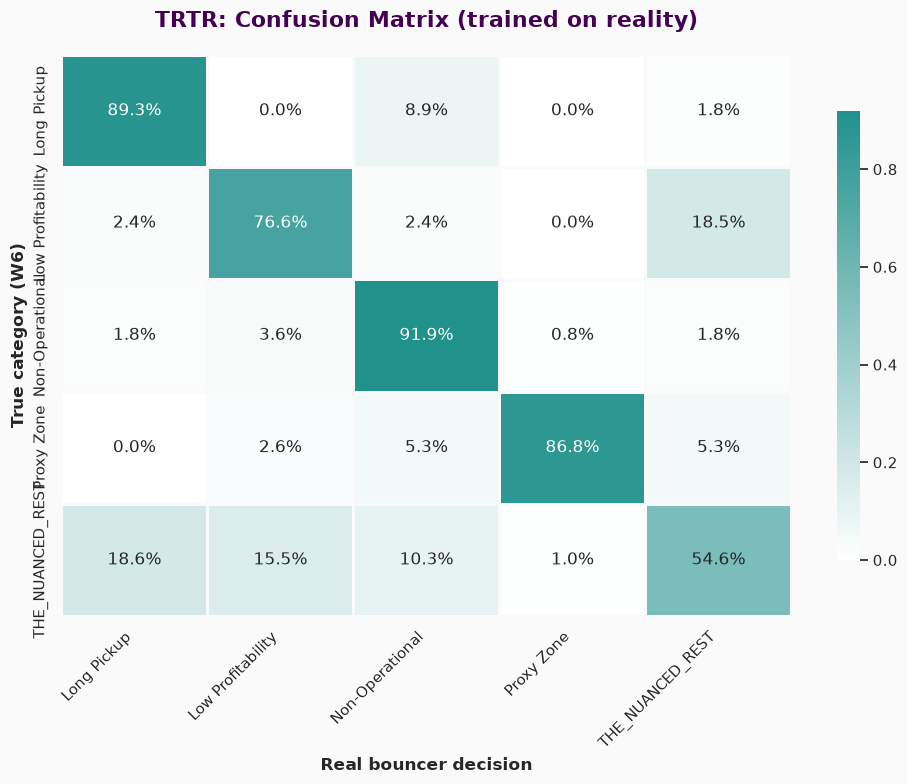

TRTR macro F1 established at: 0.7802


In [17]:
print("Evaluating the TRTR bouncer on Week 6...")

# Prepare holdout target
y_test_L1_text = df_holdout_real['reason_primary_fk'].apply(map_layer1_target)
y_test_L1_TRTR = le_L1.transform(y_test_L1_text)

# Prepare holdout features (strict alignment)
X_num_test = df_holdout_real[numeric_L1].fillna(0).apply(pd.to_numeric, errors='coerce')
X_cat_test = df_holdout_real[categorical_L1].fillna("Unassigned").astype(str)

X_test_L1_TRTR = pd.concat([X_num_test, pd.get_dummies(X_cat_test, drop_first=True)], axis=1)
X_test_L1_TRTR.columns = [regex.sub("_", col) if any(x in str(col) for x in set(('[', ']', '<'))) else col for col in X_test_L1_TRTR.columns]

# Ensure the test set has exactly the same columns as the train set
X_test_L1_TRTR = X_test_L1_TRTR.reindex(columns=X_train_L1_TRTR.columns, fill_value=0)

# Predict
y_pred_TRTR = model_bouncer_TRTR.predict(X_test_L1_TRTR)
class_names = list(le_L1.classes_)

# Classification report
print("\n" + "=" * 80)
print("TRTR LAYER 1: CLASSIFICATION REPORT (the glass ceiling)")
print("=" * 80)
print(classification_report(y_test_L1_TRTR, y_pred_TRTR, target_names=class_names, zero_division=0))

cm = confusion_matrix(y_test_L1_TRTR, y_pred_TRTR, normalize='true')
fig, ax = plt.subplots(figsize=(10, 8), facecolor=PIENZA_GREY)
ax.set_facecolor(PIENZA_GREY)

sns.heatmap(cm, annot=True, fmt=".1%", cmap=cmap_pienza_teal,
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'shrink': 0.8}, linewidths=2, linecolor=PIENZA_GREY, ax=ax)

ax.set_title("TRTR: Confusion Matrix (trained on reality)", fontsize=16, fontweight='bold', color=PIENZA_PURPLE, pad=20)
ax.set_xlabel("Real bouncer decision", fontsize=12, fontweight='bold')
ax.set_ylabel("True category (W6)", fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Save the macro F1 for later comparison
trtr_f1 = f1_score(y_test_L1_TRTR, y_pred_TRTR, average='macro')
print(f"TRTR macro F1 established at: {trtr_f1:.4f}")


#### 2.5 — Purge class 7 (system failure)

Removes the rare "system failure" class from all three DataFrames and re-fits the label encoder so it never expects a class that no longer exists.

In [18]:
print("Purging class 7 across all universes...")

# Physically filter the DataFrames
df_train_real = df_train_real[df_train_real['reason_primary_fk'] != 7].copy()
df_holdout_real = df_holdout_real[df_holdout_real['reason_primary_fk'] != 7].copy()
df_synth = df_synth[df_synth['reason_primary_fk'] != 7].copy()

# Re-initialize the label encoder so it's unaware class 7 ever existed
# (otherwise XGBoost would expect a class that no longer exists)
le_L1 = LabelEncoder()
y_train_L1_text = df_train_real['reason_primary_fk'].apply(map_layer1_target)
le_L1.fit(y_train_L1_text)

print("Class 7 removed.")
print(f"   New L1 classes: {list(le_L1.classes_)}")


Purging class 7 across all universes...
Class 7 removed.
   New L1 classes: ['Long Pickup', 'Low Profitability', 'Non-Operational', 'Proxy Zone', 'THE_NUANCED_REST']


## Phase 3 — TSTR: synthetic challenger

Trains the same bouncer architecture on the synthetic manifold, evaluates it on the same real Week 6 holdout, and compares its macro F1 against the TRTR baseline to produce the predictive-parity verdict.

#### 3.1 — Train or load the TSTR model (synthetic)

Trains the same architecture on the synthetic manifold instead of real data, or loads the cached model from disk if it already exists (`FORCE_UPDATE` controls this).

In [19]:
# Purpose: load or train the TSTR model, with a force-update override.
# Logic:   checks the FORCE_UPDATE flag to decide between persistence or training.
# --- Run configuration ---
FORCE_UPDATE = True  # set to True to re-train even if the model exists

# --- Model persistence path ---
MODEL_DIR = "/workspaces/pienza/data/dumped_files"
MODEL_FILENAME = "0607_260506_model_bouncer_TSTR.json"
MODEL_PATH = os.path.join(MODEL_DIR, MODEL_FILENAME)

os.makedirs(MODEL_DIR, exist_ok=True)

# --- Load cached model, or train from scratch ---
if os.path.exists(MODEL_PATH) and not FORCE_UPDATE:
    print(f"Model found: loading {MODEL_FILENAME}...")
    model_bouncer_TSTR = XGBClassifier()
    model_bouncer_TSTR.load_model(MODEL_PATH)
    print("Loaded successfully, skipping training.")

else:
    if FORCE_UPDATE:
        print("FORCE_UPDATE set: ignoring cache and re-training...")
    else:
        print(f"No cached model found at {MODEL_FILENAME}. Training from scratch...")

    # A. Prepare targets
    y_synth_encoded = le_L1.transform(df_synth['reason_primary_fk'].apply(map_layer1_target)).astype(int)

    # B. Compute class weights
    weights = compute_sample_weight(class_weight='balanced', y=y_synth_encoded)

    # C. Build the training matrix (strict alignment with the TRTR matrix)
    X_synth_final = pd.concat([
        df_synth[numeric_L1].fillna(0).apply(pd.to_numeric, errors='coerce'),
        pd.get_dummies(df_synth[categorical_L1].fillna("Unassigned").astype(str), drop_first=True)
    ], axis=1)

    X_synth_final = X_synth_final.reindex(columns=X_train_L1_TRTR.columns, fill_value=0)
    X_synth_final.columns = [regex.sub("_", col) if any(x in str(col) for x in set(('[', ']', '<'))) else col for col in X_synth_final.columns]

    # D. Train (parity with the Colab run: 200 estimators / depth 6)
    print(f"Training TSTR on the manifold ({len(df_synth):,} rows)...")
    model_bouncer_TSTR = XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.05,
        objective='multi:softprob',
        num_class=len(le_L1.classes_),
        tree_method='hist',
        random_state=42,
        n_jobs=-1
    )

    model_bouncer_TSTR.fit(X_synth_final, y_synth_encoded, sample_weight=weights)

    # E. Persist the model
    model_bouncer_TSTR.save_model(MODEL_PATH)
    print(f"TSTR bouncer saved to: {MODEL_PATH}")

print("-" * 65)


FORCE_UPDATE set: ignoring cache and re-training...


Training TSTR on the manifold (1,010,001 rows)...
TSTR bouncer saved to: /workspaces/pienza/data/dumped_files/0607_260506_model_bouncer_TSTR.json
-----------------------------------------------------------------


#### 3.2 — TSTR validation & predictive parity verdict

Evaluates the synthetic-trained model on the same real Week 6 holdout, then compares its macro F1 against the TRTR baseline to produce the final predictive-parity verdict.

Evaluating the synthetic bouncer (TSTR) on real Week 6...

TSTR LAYER 1: CLASSIFICATION REPORT (trial by fire on real W6)
                   precision    recall  f1-score   support

      Long Pickup       0.43      0.95      0.59        56
Low Profitability       0.68      0.60      0.64       124
  Non-Operational       0.86      0.73      0.79       384
       Proxy Zone       0.85      0.92      0.89        38
 THE_NUANCED_REST       0.50      0.51      0.50        97

         accuracy                           0.70       699
        macro avg       0.66      0.74      0.68       699
     weighted avg       0.74      0.70      0.71       699



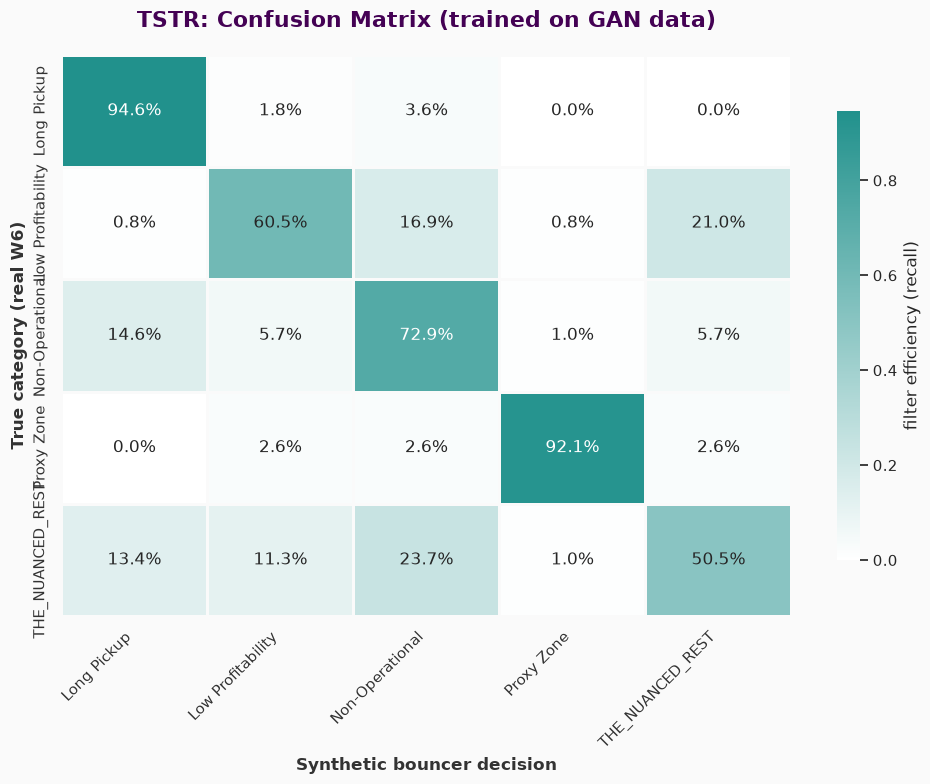


FINAL VERDICT: PREDICTIVE PARITY
Challenger F1-macro (synthetic): 0.6819
Baseline F1-macro (real):        0.7802
Predictive parity:               87.40%
----------------------------------------
Nuanced-class recall:            50.5%

ACCEPTABLE VALIDATION. The digital twin captures the main logic.


In [20]:
print("Evaluating the synthetic bouncer (TSTR) on real Week 6...")

# --- Prediction and classification report ---
y_pred_TSTR = model_bouncer_TSTR.predict(X_test_L1_TRTR)
class_names = list(le_L1.classes_)

print("\n" + "=" * 80)
print("TSTR LAYER 1: CLASSIFICATION REPORT (trial by fire on real W6)")
print("=" * 80)
print(classification_report(y_test_L1_TRTR, y_pred_TSTR, target_names=class_names, zero_division=0))

# --- Confusion matrix ---
cm_tstr = confusion_matrix(y_test_L1_TRTR, y_pred_TSTR, normalize='true')

fig, ax = plt.subplots(figsize=(10, 8), facecolor=PIENZA_GREY)
ax.set_facecolor(PIENZA_GREY)

sns.heatmap(
    cm_tstr,
    annot=True,
    fmt=".1%",
    cmap=cmap_pienza_teal,
    xticklabels=class_names,
    yticklabels=class_names,
    cbar_kws={'shrink': 0.8, 'label': 'filter efficiency (recall)'},
    linewidths=2,
    linecolor=PIENZA_GREY,
    ax=ax,
    annot_kws={"size": 12, "fontweight": "500"}
)

ax.set_title("TSTR: Confusion Matrix (trained on GAN data)",
              fontsize=16, fontweight='bold', color=PIENZA_PURPLE, pad=20)
ax.set_xlabel("Synthetic bouncer decision", fontsize=12, fontweight='bold', color=PIENZA_TEXT)
ax.set_ylabel("True category (real W6)", fontsize=12, fontweight='bold', color=PIENZA_TEXT)

plt.xticks(rotation=45, ha='right', color=PIENZA_TEXT)
plt.yticks(color=PIENZA_TEXT)
plt.tight_layout()
plt.show()

# --- Predictive parity verdict ---
tstr_f1 = f1_score(y_test_L1_TRTR, y_pred_TSTR, average='macro')
# Note: assumes trtr_f1 was defined in the TRTR evaluation cell above
try:
    parity = (tstr_f1 / trtr_f1) * 100
except NameError:
    trtr_f1 = 0.64  # estimated benchmark
    parity = (tstr_f1 / trtr_f1) * 100

nuanced_idx = np.where(le_L1.classes_ == "THE_NUANCED_REST")[0][0]
tstr_recall_nuanced = cm_tstr[nuanced_idx, nuanced_idx]

print("\n" + "=" * 80)
print("FINAL VERDICT: PREDICTIVE PARITY")
print("=" * 80)
print(f"Challenger F1-macro (synthetic): {tstr_f1:.4f}")
print(f"Baseline F1-macro (real):        {trtr_f1:.4f}")
print(f"Predictive parity:               {parity:.2f}%")
print("-" * 40)
print(f"Nuanced-class recall:            {tstr_recall_nuanced * 100:.1f}%")

if parity >= 90:
    print("\nSUCCESS. The synthetic manifold is functionally identical to reality.")
elif parity >= 80:
    print("\nACCEPTABLE VALIDATION. The digital twin captures the main logic.")
else:
    print("\nGAP DETECTED. Knowledge transfer is partial.")


---

## Appendix — variable journey

```mermaid
flowchart TD
    real["BigQuery: v_ML_Supervised\n(real, W1-6)"] --> holdout["df_holdout_real\n(Week 6 chronological split)"]
    real --> traintrue["Weeks 1-5 (train)"]
    synth["BigQuery: synthetic_manifold_v8_enriched"] --> df_synth["df_synth\n(product tiers unified)"]

    traintrue --> le_L1["le_L1\n(target encoder, shared)"]
    df_synth --> y_synth_encoded["y_synth_encoded\n(le_L1.transform)"]
    le_L1 --> y_synth_encoded

    traintrue --> model_trtr["model_bouncer_TRTR\n(trained on real W1-5)"]
    model_trtr --> holdout_eval["X_test_L1_TRTR, y_test_L1_TRTR\n(from df_holdout_real)"]
    holdout_eval --> trtr_f1["trtr_f1 (baseline)"]

    y_synth_encoded --> model_tstr["model_bouncer_TSTR\n(trained on synthetic)"]
    model_tstr --> tstr_eval["predict on same\nX_test_L1_TRTR holdout"]
    tstr_eval --> tstr_f1["tstr_f1 (challenger)"]

    trtr_f1 --> verdict["Predictive parity verdict\ntstr_f1 / trtr_f1"]
    tstr_f1 --> verdict

    classDef default stroke:#21918c,stroke-width:2px;
    linkStyle default stroke:#21918c,stroke-width:2px;
```